2025-06-11 18:57:26.033825: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-11 18:57:26.064609: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-11 18:57:26.064628: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-11 18:57:26.065590: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-11 18:57:26.071117: I tensorflow/core/platform/cpu_feature_guar

[]


2025-06-11 18:57:27.235626: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_COMPAT_NOT_SUPPORTED_ON_DEVICE: forward compatibility was attempted on non supported HW
2025-06-11 18:57:27.235648: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:129] retrieving CUDA diagnostic information for host: balanis
2025-06-11 18:57:27.235651: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:136] hostname: balanis
2025-06-11 18:57:27.235729: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:159] libcuda reported version is: 550.144.3
2025-06-11 18:57:27.235741: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:163] kernel reported version is: 550.120.0
2025-06-11 18:57:27.235743: E external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:244] kernel version 550.120.0 does not match DSO version 550.144.3 -- cannot find working devices in this configuration


data ['LA_RSPV_CAF_150115', 'Simulation_01_200428_001_001', 'Simulation_01_200316_001_  5', 'Simulation_01_191001_001_002', 'Simulation_01_200428_001_005', 'Simulation_01_190717_001_001', 'Simulation_01_200212_001_  7', 'Simulation_01_191001_001_007', 'LA_RSPV_150113', 'Simulation_01_210119_001_001', 'Simulation_01_210205_001_003', 'LA_PLAW_140612', 'Simulation_01_190717_001_004', 'Simulation_01_201223_001_002', 'Simulation_01_200212_001_  1', 'LA_LSPV_150203', 'Simulation_01_190619_001_003', 'Simulation_01_200428_001_003', 'Simulation_01_190619_001_004', 'Simulation_01_190717_001_003', 'Simulation_01_190502_001_006', 'LA_LSPV_150113', 'Simulation_01_190502_001_004', 'RA_RAFW_140807', 'Simulation_01_190717_001_002', 'Simulation_01_200316_001_  3', 'Simulation_01_200316_001_  4', 'RA_RAA_141230', 'Sinusal_150629', 'RA_RAA_141216', 'Simulation_01_200428_001_002', 'Simulation_01_210210_001_001', 'Simulation_01_210208_001_002', 'Simulation_01_190619_001_001', 'Simulation_01_200212_001_  9'

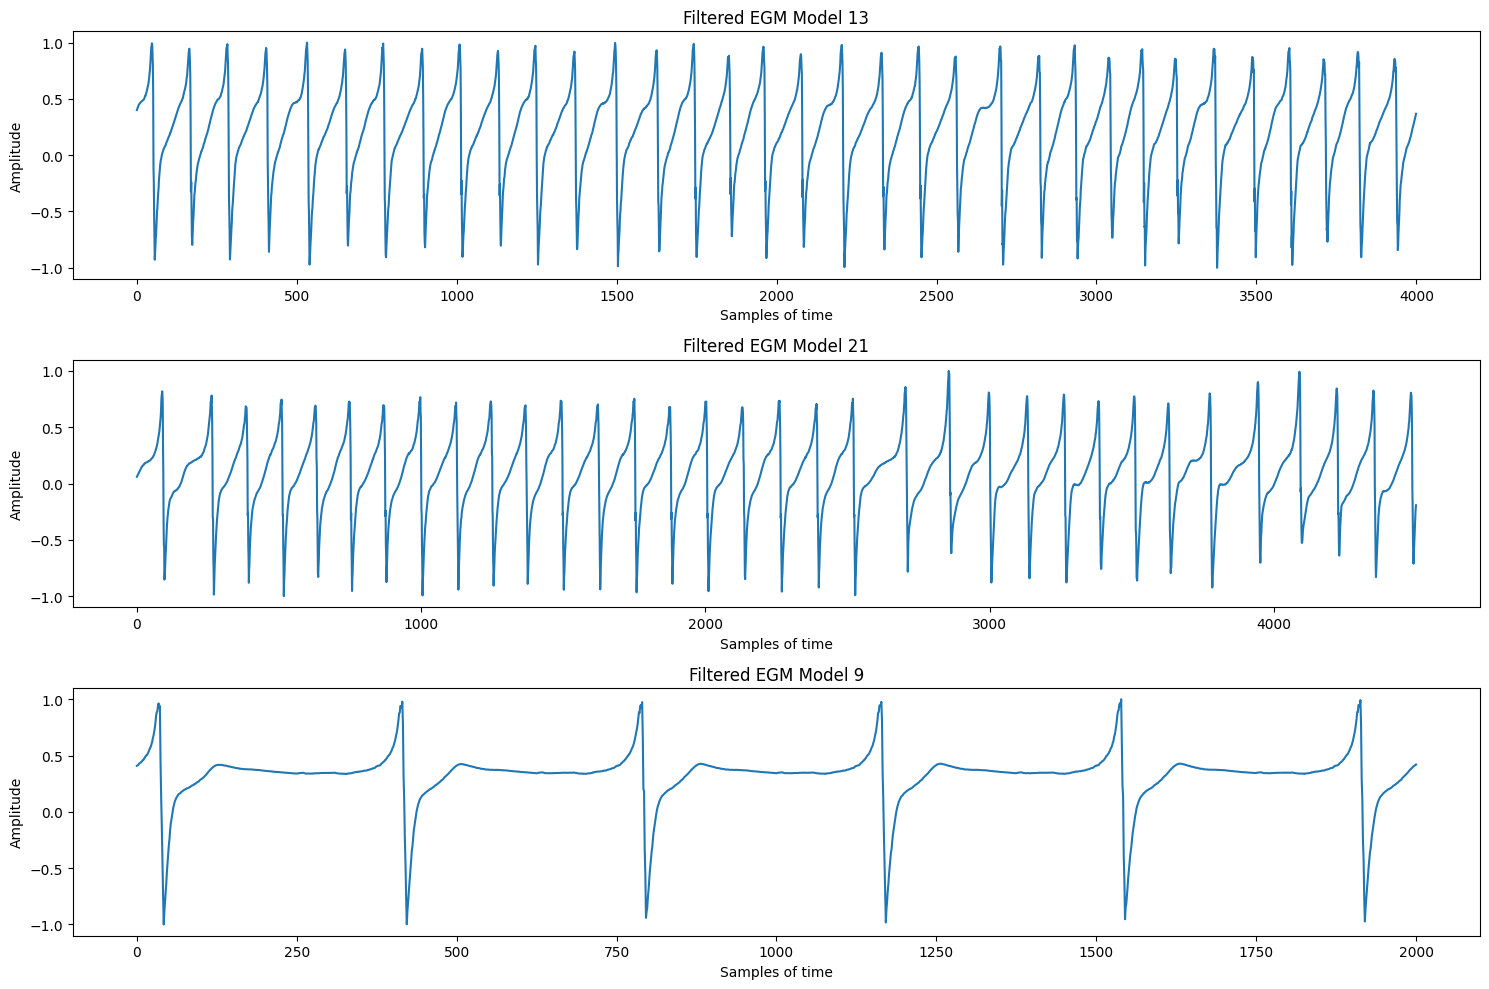

10
Transfer matrices LOADED - var: **transfer_matrices** 
BSPS Models LOADED - var: **bsps_all_models** 
BSPS 64 Models LOADED - var: **bsps_64_all_models** 
550
(3610, 2499)
(3610, 2499)
(64, 2499)
(3970, 2499)
(64, 2499)
(64, 2001)
550
BSPS 64 Models LOADED - var: **bsps_64_all_models** 


In [1]:
import os
os.environ["XLA_FLAGS"] = "--xla_gpu_cuda_data_dir=/home/alumnos/mburgosc/cuda-fake"

import tensorflow as tf

import tensorflow as tf 
import numpy as np
gpus = tf.config.list_physical_devices("GPU")

print(gpus)

import import_data

egms_all_models = import_data.egms_all_models
egms_values = import_data.egms_values
egms_filtered_norm = import_data.egms_filtered_norm
bsps_all_models = import_data.bsps_all_models
bsps_64_all_models = import_data.bsps_64_all_models
transfer_matrices = import_data.transfer_matrices
models_names = import_data.models_names
bsps_64_all_models_names = import_data.bsps_64_all_models_names

In [2]:
print(bsps_64_all_models_names[:100])
print(len(bsps_64_all_models_names))
# models_name_full = []
# for name in models_names:
#     models_name_full.extend([name] * 10)

models_name_full = bsps_64_all_models_names
# Verifica que coinciden
print(len(models_name_full))  # Debería dar 240
filtered_models = []
filtered_models_names = []

for model, name_model in zip(bsps_64_all_models, models_name_full):
    new_model = []
    new_model2 = []

    for node in model:
        original_length = len(node)

        if original_length < 2000:
            continue

        if 2000 <= original_length <= 2501:
            node = node[:2000]
            new_model.append(node)
        elif 4000 <= original_length <= 4501:
            node = node[:4000]
            new_model.append(node[0:2000])
            new_model2.append(node[2000:4000])
        else:
            continue


    if len(new_model) > 0:
        filtered_models.append(new_model)
        filtered_models_names.append(name_model)  # Añadimos el nombre del modelo
    if len(new_model2) > 0:
        filtered_models.append(new_model2)
        filtered_models_names.append(name_model)
        
bsps_64_filtered_models = filtered_models

print(len(bsps_64_filtered_models))
print(len(filtered_models_names))
print(filtered_models_names)
print(bsps_64_filtered_models[0])

print(filtered_models_names[140])

['LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_191001_001_002', 'Simulation_01_191001_001_002', 'Simulation_01_191001_001_002', 'Simulation_01_191001_001_002', 'Simulation_01_191001_001_002', 'Simulation_01_191001_001_002', 'Simulation_01_191001_001_002', 'Simulation_01_191001_001_002', 'Simulation_01_191001_001_002', 'Simulation_01_191001_001_002', 'Simulation_01_200428_001_005', 'Simulation_01_200428_001_005', 'Simulation_01_200428_001_005', 'Simulation_01_200428_001_005', 'Simulation

In [3]:
from collections import OrderedDict
unique_models = list(OrderedDict.fromkeys(filtered_models_names))
print(len(unique_models))
print(unique_models)

model_to_indices = {m: [] for m in unique_models}  # DICCIONARIO CON NOMBRES DE MODELOS Y SUS INDICES EN filtered_models_names
for i, name in enumerate(filtered_models_names):
    if name in unique_models:
        model_to_indices[name].append(i)
print(f"Índices de modelos: {model_to_indices}")

54
['LA_RSPV_CAF_150115', 'Simulation_01_200316_001_  5', 'Simulation_01_191001_001_002', 'Simulation_01_200428_001_005', 'Simulation_01_190717_001_001', 'Simulation_01_200212_001_  7', 'Simulation_01_191001_001_007', 'LA_RSPV_150113', 'Simulation_01_190717_001_004', 'Simulation_01_200212_001_  1', 'LA_LSPV_150203', 'Simulation_01_190619_001_003', 'Simulation_01_200428_001_003', 'Simulation_01_190619_001_004', 'Simulation_01_190717_001_003', 'Simulation_01_190502_001_006', 'LA_LSPV_150113', 'Simulation_01_190502_001_004', 'RA_RAFW_140807', 'Simulation_01_190717_001_002', 'Simulation_01_200316_001_  3', 'Simulation_01_200316_001_  4', 'RA_RAA_141230', 'Sinusal_150629', 'RA_RAA_141216', 'Simulation_01_190619_001_001', 'Simulation_01_200212_001_  9', 'Simulation_01_200316_001_  1', 'Simulation_01_200316_001_  8', 'Simulation_01_200428_001_004', 'Simulation_01_200212_001_  8', 'Simulation_01_200212_001_ 10', 'Simulation_01_191001_001_001', 'Simulation_01_200428_001_007', 'Simulation_01_200

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split


# Leer el CSV
csv_df = pd.read_csv('annotations.csv', header=None)

# Separar por ';'
csv_split = csv_df[0].str.split(';', expand=True)
csv_names = csv_split[0].str.strip().tolist()  # Eliminar espacios
csv_labels = csv_split[1].astype(int).tolist()

# Lista de modelos únicos que quieres filtrar (asegúrate de que está definida)
# unique_models = [...]

# Crear un diccionario con todos los nombres y etiquetas
name_to_label = dict(zip(csv_names, csv_labels))

# Filtrar sólo los que están en unique_models
filtered_unique_models = [m for m in unique_models if name_to_label.get(m) != 1]
print(len(filtered_unique_models))

filtered_labels = [name_to_label[m] for m in filtered_unique_models]

train_models, test_models, train_labels, test_labels = train_test_split(
    filtered_unique_models,
    filtered_labels,
    test_size=0.3,
    stratify=filtered_labels,
    random_state=42
)

# Mostrar resultados
print(filtered_labels)
print(len(filtered_labels))

print("Total modelos únicos con etiqueta:", len(filtered_unique_models))


print("Modelos de entrenamiento:", len(train_models))
print("Modelos de prueba:", len(test_models))
print("Etiquetas de entrenamiento:", len(train_labels))
print("Etiquetas de prueba:", len(test_labels))

# Opcional: Ver distribución
from collections import Counter
print("Distribución train:", Counter(train_labels))
print("Distribución test:", Counter(test_labels))

52
[3, 4, 2, 4, 2, 4, 2, 3, 2, 4, 3, 2, 4, 2, 2, 2, 3, 2, 3, 2, 4, 2, 3, 4, 2, 4, 4, 2, 2, 2, 2, 2, 4, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 3, 2, 2, 2, 3, 4]
52
Total modelos únicos con etiqueta: 52
Modelos de entrenamiento: 36
Modelos de prueba: 16
Etiquetas de entrenamiento: 36
Etiquetas de prueba: 16
Distribución train: Counter({2: 21, 4: 9, 3: 6})
Distribución test: Counter({2: 10, 4: 4, 3: 2})


In [5]:
X_train = []
y_train = []

for model_name, label in zip(train_models, train_labels):
    indices = model_to_indices.get(model_name, [])
    for idx in indices:
        X_train.append(filtered_models[idx])
        y_train.append(label)

X_test = []
y_test = []

for model_name, label in zip(test_models, test_labels):
    indices = model_to_indices.get(model_name, [])
    for idx in indices:
        X_test.append(filtered_models[idx])
        y_test.append(label)

# Verificación rápida
print(f"Total X_train: {len(X_train)}, y_train: {len(y_train)}")
print(f"Total X_test: {len(X_test)}, y_test: {len(y_test)}")

print(Counter(y_train))
print(Counter(y_test))

X_train = np.array(X_train)
X_test = np.array(X_test)


Total X_train: 560, y_train: 560
Total X_test: 250, y_test: 250
Counter({2: 410, 4: 90, 3: 60})
Counter({2: 190, 4: 40, 3: 20})


In [6]:
# FUNCTIONS --> ADD_NOISE + FILTERING
from scipy.signal import butter, filtfilt
from add_white_noise import addwhitenoise

# Parámetros
fs = 500  # Frecuencia de muestreo
cutoff = 40  # Frecuencia de corte del filtro LPF

# Función para crear y aplicar un filtro paso bajo
def lowpass_filter(signal, cutoff, fs, order=4):
    nyq = 0.5 * fs  # Frecuencia de Nyquist
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    filtered_signal = filtfilt(b, a, signal)
    return filtered_signal

# Selecciona el modelo

def extract_filtered_data(X, fs, SNR, cutoff):
    filtered_data = []
    for model in X:
        model = np.array(model)
        model = model - np.mean(model, axis=1, keepdims=True)  # Centrado
        model_noisy_T, _ = addwhitenoise(model, SNR=SNR, fs=fs, plot_figure='False')
        model_noisy = model_noisy_T
        senal_filtrada = lowpass_filter(model_noisy, cutoff=cutoff, fs=fs)
        filtered_data.append(senal_filtrada)
    return np.array(filtered_data)

X_train_filt_10dB = extract_filtered_data(X_train, fs=500, SNR=10, cutoff=40)
X_test_filt_10dB = extract_filtered_data(X_test, fs=500, SNR=10, cutoff=40)

print(f"Datos filtrados: {X_train_filt_10dB.shape}, {X_test_filt_10dB.shape}")

X_train_filt_20dB = extract_filtered_data(X_train, fs=500, SNR=20, cutoff=40)
X_test_filt_20dB = extract_filtered_data(X_test, fs=500, SNR=20, cutoff=40)

print(f"Datos filtrados: {X_train_filt_10dB.shape}, {X_test_filt_10dB.shape}")


Datos filtrados: (560, 64, 2000), (250, 64, 2000)
Datos filtrados: (560, 64, 2000), (250, 64, 2000)


In [7]:
# PRINCIPAL COMPONENT ANALYSIS (PCA)

from sklearn.decomposition import PCA

def apply_pca(X, n_components=3):
    # APLICAR PCA A CADA MODELO
    n_components = 3
    X_pca = []
    for model in X:
        model_T = model.T  # Transponer para que las muestras sean filas
        pca = PCA(n_components=n_components)
        model_pca = pca.fit_transform(model_T)  # (1000, 2)

        # Si quieres devolverlo como (64, 2) puedes transponer de nuevo
        model_pca = model_pca.T  # (2, 1000)
        X_pca.append(model_pca)

    return np.array(X_pca)

#original_data
X_train_pca = apply_pca(X_train, n_components=3)
X_test_pca = apply_pca(X_test, n_components=3)

#filtered_data_10dB
X_train_filt_10dB_pca = apply_pca(X_train_filt_10dB, n_components=3)
X_test_filt_10dB_pca = apply_pca(X_test_filt_10dB, n_components=3)

#filtered_data_20dB
X_train_filt_20dB_pca = apply_pca(X_train_filt_20dB, n_components=3)
X_test_filt_20dB_pca = apply_pca(X_test_filt_20dB, n_components=3)


print(f"PCA aplicado por modelo. Ejemplo dimensiones: {X_train_pca[0].shape} (3 componentes x 500 muestras)")
print(f"PCA aplicado por modelo. Ejemplo dimensiones: {X_train_filt_10dB_pca[0].shape} (3 componentes x 500 muestras)")
print(f"PCA aplicado por modelo. Ejemplo dimensiones: {X_train_filt_20dB_pca[0].shape} (3 componentes x 500 muestras)")
print(f"No PCA applied. Ejemplo dimensiones: {X_train[0].shape} (64 canales x 500 muestras)")

PCA aplicado por modelo. Ejemplo dimensiones: (3, 2000) (3 componentes x 500 muestras)
PCA aplicado por modelo. Ejemplo dimensiones: (3, 2000) (3 componentes x 500 muestras)
PCA aplicado por modelo. Ejemplo dimensiones: (3, 2000) (3 componentes x 500 muestras)
No PCA applied. Ejemplo dimensiones: (64, 2000) (64 canales x 500 muestras)


In [8]:
# WAVELET SCATTERING TRANSFORM

from kymatio import Scattering1D

def apply_wavelet_scattering(X, J=4, Q=(16, 1)):
    # APLICAR SCATTERING A CADA MODELO
    J = 4
    Q = (16,1)

    ws_coeffs = []  

    for model in X:
        model_coeffs = []  
        
        for j in range(len(model)):
            signal = np.array(model[j])  
            len_signal = len(signal)
            
            scattering = Scattering1D(J=J, shape=(len_signal,), Q=Q)
            Sx = scattering(signal)  
            model_coeffs.append(Sx)  
        ws_coeffs.append(np.stack(model_coeffs))
    return np.array(ws_coeffs)

#original_data
X_train_ws = apply_wavelet_scattering(X_train_pca)
X_test_ws = apply_wavelet_scattering(X_test_pca)

#filtered_data_10dB
X_train_filt_10dB_ws = apply_wavelet_scattering(X_train_filt_10dB_pca)
X_test_filt_10dB_ws = apply_wavelet_scattering(X_test_filt_10dB_pca)

#filtered_data_20dB
X_train_filt_20dB_ws = apply_wavelet_scattering(X_train_filt_20dB_pca)
X_test_filt_20dB_ws = apply_wavelet_scattering(X_test_filt_20dB_pca)

#original_data NO PCA
X_train_ws_no_pca = apply_wavelet_scattering(X_train)
X_test_ws_no_pca = apply_wavelet_scattering(X_test)

print(f"Scattering aplicado por modelo. Ejemplo dimensiones: {X_train_ws[0].shape} ")
print(f"Scattering aplicado por modelo. Ejemplo dimensiones: {X_train_filt_10dB_ws[0].shape} ")
print(f"Scattering aplicado por modelo. Ejemplo dimensiones: {X_train_filt_20dB_ws[0].shape} ")
print(f"Scattering aplicado por modelo. Ejemplo dimensiones: {X_train_ws_no_pca[0].shape} ")



Scattering aplicado por modelo. Ejemplo dimensiones: (3, 74, 125) 
Scattering aplicado por modelo. Ejemplo dimensiones: (3, 74, 125) 
Scattering aplicado por modelo. Ejemplo dimensiones: (3, 74, 125) 
✅ Scattering aplicado por modelo. Ejemplo dimensiones: (64, 74, 125) 


In [9]:
X_train_final = X_train_ws.reshape(X_train_ws.shape[0], -1)
X_test_final = X_test_ws.reshape(X_test_ws.shape[0], -1)

X_train_filt_10dB_final = X_train_filt_10dB_ws.reshape(X_train_filt_10dB_ws.shape[0], -1)
X_test_filt_10dB_final = X_test_filt_10dB_ws.reshape(X_test_filt_10dB_ws.shape[0], -1)

X_train_filt_20dB_final = X_train_filt_20dB_ws.reshape(X_train_filt_20dB_ws.shape[0], -1)
X_test_filt_20dB_final = X_test_filt_20dB_ws.reshape(X_test_filt_20dB_ws.shape[0], -1)

X_train_no_pca_final = X_train_ws_no_pca.reshape(X_train_ws_no_pca.shape[0], -1)
X_test_no_pca_final = X_test_ws_no_pca.reshape(X_test_ws_no_pca.shape[0], -1)

print(f"Datos finales: {X_train_final.shape}, {X_test_final.shape}")
print(f"Datos finales filtrados 10dB: {X_train_filt_10dB_final.shape}, {X_test_filt_10dB_final.shape}")
print(f"Datos finales filtrados 20dB: {X_train_filt_20dB_final.shape}, {X_test_filt_20dB_final.shape}")
print(f"Datos finales sin PCA: {X_train_no_pca_final.shape}, {X_test_no_pca_final.shape}")

Datos finales: (560, 27750), (250, 27750)
Datos finales filtrados 10dB: (560, 27750), (250, 27750)
Datos finales filtrados 20dB: (560, 27750), (250, 27750)
Datos finales sin PCA: (560, 592000), (250, 592000)


In [ ]:
# RANDOM FOREST CLASSIFIER
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, log_loss, f1_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import recall_score, precision_score

def apply_random_forest(X_train_final, y_train, X_test_final, y_test):
    rf = RandomForestClassifier(class_weight='balanced', n_estimators=1000, max_depth=40, random_state=42, 
                            max_features=None, min_samples_split=4, min_samples_leaf=2, bootstrap=True)

    rf.fit(X_train_final, y_train)

    # Predecir y evaluar en test
    y_pred = rf.predict(X_test_final)

    cm = confusion_matrix(y_test, y_pred)

    sensitivity = recall_score(y_test, y_pred, average='macro')  # o 'weighted'
    specificity = precision_score(y_test, y_pred, average='macro')  # Approximation

    acc = accuracy_score(y_test, y_pred)
    y_proba = rf.predict_proba(X_test_final)[:, 1]

    classes = np.unique(y_test)
    y_test_bin = label_binarize(y_test, classes=classes)
    auc_roc = roc_auc_score(y_test_bin, y_proba, multi_class='ovr')
    log_loss_value = log_loss(y_test, y_proba)
    f1_score_value = f1_score(y_test, rf.predict(X_test_final))

    print(classification_report(y_test, y_pred))
    print("Accuracy:", acc)
    print("Confusion Matrix:\n", cm)
    print("Sensitivity (Recall):", sensitivity)
    print("Specificity:", specificity)
    print("AUC-ROC:", roc_auc)
    print("Log loss:", log_loss_value)

    return acc, cm, sensitivity, specificity, y_proba, auc_roc, log_loss_value, f1_score_value

# original_data
acc, cm, sensitivity, specificity, y_proba, roc_auc, log_loss_, f1_score_ = apply_random_forest(X_train_final, y_train, X_test_final, y_test)
# filtered_data_10dB
acc_filt_10dB, cm_filt_10dB, sensitivity_filt_10dB, specificity_filt_10dB, y_proba_filt_10dB, roc_auc_filt_10dB, log_loss_filt_10dB, f1_score_filt_10dB = apply_random_forest(X_train_filt_10dB_final, y_train, X_test_filt_10dB_final, y_test)
# filtered_data_20dB
acc_filt_20dB, cm_filt_20dB, sensitivity_filt_20dB, specificity_filt_20dB, y_proba_filt_20dB, roc_auc_filt_20dB, log_loss_filt_20dB, f1_score_filt_20dB = apply_random_forest(X_train_filt_20dB_final, y_train, X_test_filt_20dB_final, y_test)
# no PCA
acc_no_pca, cm_no_pca, sensitivity_no_pca, specificity_no_pca, y_proba_no_pca, roc_auc_no_pca, log_loss_no_pca, f1_score_no_pca = apply_random_forest(X_train_no_pca_final, y_train, X_test_no_pca_final, y_test)

ValueError: too many values to unpack (expected 4)